In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os, subprocess, sys
from pathlib import Path
REPO_URL = "https://github.com/SagarInspires/crowd-intelligence.git"
REPO_DIR = "/kaggle/working/crowd-intelligence"
def sync_repo():
    """Clone the repo on a fresh session, or pull the newest code if it is already
    there, then make the `src` folder importable."""
    if os.path.isdir(REPO_DIR):
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    else:
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
sync_repo()

Cloning into '/kaggle/working/crowd-intelligence'...


In [3]:
import numpy as np, pandas as pd, cv2, torch
from pathlib import Path
from src.data.via import load_ground_truth
from src.evaluation.detection import eval_frame, summarise, cluster_bootstrap_ci

DATA = Path(f"{REPO_DIR}/data/your_video")
pts, ign, _ = load_ground_truth(DATA)                       # same 6,816 points as notebook 01, no CSV needed
SHAPE = cv2.imread(str(DATA / "annotated_frames/frame_00000.jpg")).shape[:2]   # (H, W)
DETECT_DIR = Path("/kaggle/working/outputs/detections"); DETECT_DIR.mkdir(parents=True, exist_ok=True)
print(len(pts), "points,", pts.frame_id.nunique(), "frames, frame size (H, W) =", SHAPE, "| GPU:", torch.cuda.is_available())

6816 points, 15 frames, frame size (H, W) = (1920, 1080) | GPU: True


In [4]:
# Install the YOLO library (one time per session; needs Internet ON in notebook settings)
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 822.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.8 MB/s eta 0:00:00


In [5]:
import numpy as np, torch
from ultralytics import YOLO

def detect_frames(model, paths, imgsz=1920, conf_floor=0.05, max_det=3000):
    """Run a person detector on frames with a LOW confidence floor (thresholds are tuned later, offline).
    max_det is raised because the default of 300 would cap the count in a 500-person frame."""
    out = {}
    for p in paths:
        r = model.predict(str(p), imgsz=imgsz, classes=[0], conf=conf_floor, iou=0.7,
                          max_det=max_det, verbose=False)[0]
        out[p.stem] = (r.boxes.xyxy.cpu().numpy().astype(np.float32), r.boxes.conf.cpu().numpy().astype(np.float32))
    return out

frames = sorted((DATA / "annotated_frames").glob("frame_*.jpg"))
MODELS = ["yolov8x.pt", "yolo26x.pt"]                      # same image size, same frames, same threshold floor
dets = {}
for name in MODELS:
    dets[name] = detect_frames(YOLO(name), frames)         # weights download on first use
    np.savez_compressed(DETECT_DIR / f"{name[:-3]}_15frames.npz",
                        **{f"{k}_boxes": v[0] for k, v in dets[name].items()},
                        **{f"{k}_conf": v[1] for k, v in dets[name].items()})
    counts = {k: len(v[0]) for k, v in dets[name].items()}
    print(name, counts)
    print("   frames hitting the max_det cap (should be none):", [k for k, c in counts.items() if c >= 3000])

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
yolov8x.pt {'frame_00000': 134, 'frame_00093': 111, 'frame_00186': 112, 'frame_00279': 105, 'frame_00372': 89, 'frame_00465': 83, 'frame_00558': 98, 'frame_00651': 93, 'frame_00744': 98, 'frame_00837': 99, 'frame_00930': 103, 'frame_01023': 93, 'frame_01116': 83, 'frame_01209': 78, 'frame_01302': 90}
   frames hitting the max_det cap (should be none): []
yolo26x.pt {'frame_00000': 290, 'frame_00093': 276, 'frame_00186': 270, 'frame_00279': 269, 'frame_00372': 289, 'frame_00465': 270, 'frame_00558': 260, 'frame_00651': 265, 'frame_00744': 266, 'frame_00837': 265, 'frame_00930': 276, 'frame_01023': 264, 'frame_01116': 255, 'frame_01209': 246, 'frame_01302': 259}
   frames hitting the max_det cap (sho

In [6]:
import ultralytics, numpy as np
print("ultralytics version:", ultralytics.__version__)

def count_boxes(model, path, **kw):
    """Number of person boxes for one frame under given predict() settings; returns the error text if a setting is rejected."""
    try:
        r = model.predict(str(path), imgsz=1920, classes=[0], conf=0.05, max_det=3000, verbose=False, **kw)[0]
        return len(r.boxes)
    except Exception as e:
        return f"error: {str(e)[:100]}"

m26 = YOLO("yolo26x.pt")
f0 = DATA / "annotated_frames/frame_00000.jpg"
for label, kw in [("default", {}), ("end2end=False", dict(end2end=False)),
                  ("nms=True", dict(nms=True)), ("nms=False", dict(nms=False))]:
    print(f"{label:14s}", count_boxes(m26, f0, **kw))

ultralytics version: 8.4.165
default        290
WARNING ⚠️ 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
end2end=False  290
nms=True       290
nms=False      286


In [7]:
def count_at(model, path, conf, **kw):
    """Box count for one frame at a given confidence floor (nearly all candidates when conf is tiny)."""
    r = model.predict(str(path), imgsz=1920, classes=[0], conf=conf, max_det=3000, verbose=False, **kw)[0]
    return len(r.boxes)

m8 = YOLO("yolov8x.pt")
print("conf     yolov8x   yolo26x(nms=True)   yolo26x(nms=False)")
for c in [0.25, 0.05, 0.01, 0.001]:
    print(f"{c:<8} {count_at(m8, f0, c):<9} {count_at(m26, f0, c, nms=True):<19} {count_at(m26, f0, c, nms=False)}")

conf     yolov8x   yolo26x(nms=True)   yolo26x(nms=False)
0.25     17        53                  44
0.05     134       290                 286
0.01     378       648                 612
0.001    1245      1658                1456


In [8]:
MODELS = ["yolov8x.pt", "yolo26x.pt"]
models = {"yolov8x.pt": m8, "yolo26x.pt": m26}          # reuse the models already loaded in this session

def detect_frames(model, paths, imgsz=1920, conf_floor=0.01, max_det=3000):
    """Run a person detector on frames with a LOW confidence floor (the real cutoff is tuned later, offline).
    max_det is raised because the default of 300 would cap the count in a 500-person frame."""
    out = {}
    for p in paths:
        r = model.predict(str(p), imgsz=imgsz, classes=[0], conf=conf_floor, iou=0.7,
                          max_det=max_det, verbose=False)[0]
        out[p.stem] = (r.boxes.xyxy.cpu().numpy().astype(np.float32), r.boxes.conf.cpu().numpy().astype(np.float32))
    return out

frames = sorted((DATA / "annotated_frames").glob("frame_*.jpg"))
dets = {}
for name in MODELS:
    dets[name] = detect_frames(models[name], frames)
    np.savez_compressed(DETECT_DIR / f"{name[:-3]}_15frames.npz",
                        **{f"{k}_boxes": v[0] for k, v in dets[name].items()},
                        **{f"{k}_conf": v[1] for k, v in dets[name].items()})
    print(name, {k: len(v[0]) for k, v in dets[name].items()})    # raw boxes per frame at confidence >= 0.01

yolov8x.pt {'frame_00000': 378, 'frame_00093': 329, 'frame_00186': 358, 'frame_00279': 320, 'frame_00372': 305, 'frame_00465': 252, 'frame_00558': 303, 'frame_00651': 283, 'frame_00744': 316, 'frame_00837': 300, 'frame_00930': 296, 'frame_01023': 302, 'frame_01116': 289, 'frame_01209': 275, 'frame_01302': 313}
yolo26x.pt {'frame_00000': 612, 'frame_00093': 607, 'frame_00186': 585, 'frame_00279': 562, 'frame_00372': 589, 'frame_00465': 574, 'frame_00558': 601, 'frame_00651': 566, 'frame_00744': 574, 'frame_00837': 559, 'frame_00930': 599, 'frame_01023': 584, 'frame_01116': 593, 'frame_01209': 562, 'frame_01302': 582}


## Step 5: Run both detectors on the 15 frames

**In simple words:** we show YOLO each of our 15 frames at full resolution (1920 pixels tall, so far-away heads are not shrunk to nothing) and ask it for **person** boxes only. We keep even very unsure boxes (confidence 0.01 and above) and choose the real cutoff later, on separate tuning frames. We save the boxes to a file, because the crowd masks for camera registration will need them.

**Why two detectors:** YOLOv8x is our earlier baseline; YOLO26x is the newer generation. Same frames and same settings, so the comparison is fair.

In [9]:
ids = sorted(pts.frame_id.unique())
tune_ids = ids[1::3]                                      # 5 frames used ONLY to choose the confidence cutoff
test_ids = [i for i in ids if i not in tune_ids]          # 10 frames used ONLY for the reported results
far_y = SHAPE[0] / 2                                      # rows above the middle count as "far"
thresholds = [0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

def score_model(det):
    """Tune the confidence cutoff on the tuning frames, then score the reporting frames only. Returns (cutoff, per-frame table)."""
    rec = {i: (pts[pts.frame_id == i][["x", "y"]].to_numpy(float), *det[f"frame_{i:05d}"],
               ign[ign.frame_id == i]["vertices"].tolist()) for i in ids}
    def rows(fids, thr):
        """One metrics row per frame at confidence cutoff thr."""
        return pd.DataFrame([dict(frame_id=i, **eval_frame(rec[i][0], rec[i][1], rec[i][2], rec[i][3], thr, far_y))
                             for i in fids])
    best = max(thresholds, key=lambda t: summarise(rows(tune_ids, t))["F1"])
    return best, rows(test_ids, best)

results = {}
for name in MODELS:
    best, res = score_model(dets[name]); S = summarise(res)
    lo, hi = cluster_bootstrap_ci((res.n_det - res.n_true).abs())
    results[name] = dict(conf_cutoff=best, MAE=S["MAE"], MAE_95CI=f"{lo:.0f}-{hi:.0f}", bias=S["bias"],
                         precision=S["precision"], recall=S["recall"],
                         recall_far=S["recall_far"], recall_near=S["recall_near"])
    res.to_csv(DETECT_DIR / f"E001_{name[:-3]}_per_frame.csv", index=False)

summary = pd.DataFrame(results).T
summary.to_csv(DETECT_DIR / "E001_summary.csv")
print("tuning frames:", tune_ids, "| reporting frames:", test_ids)
print(summary.round(3).to_string())

tuning frames: [np.int64(93), np.int64(372), np.int64(651), np.int64(930), np.int64(1209)] | reporting frames: [np.int64(0), np.int64(186), np.int64(279), np.int64(465), np.int64(558), np.int64(744), np.int64(837), np.int64(1023), np.int64(1116), np.int64(1302)]
           conf_cutoff    MAE MAE_95CI   bias precision    recall recall_far recall_near
yolov8x.pt        0.01  149.1  137-160 -149.1  0.777418  0.524443    0.21064    0.661235
yolo26x.pt        0.02   44.3    26-62  -42.9  0.745004  0.675251   0.424155    0.784707


## Step 6: Score the detectors against the heads we clicked

**In simple words:** for each detector we ask "of the people we clicked, how many did it find?" A box counts as a hit if its head position lies close to a clicked head (each head can be matched only once). Then:
- **Recall** = the share of real people it found.
- **Precision** = the share of its boxes that were real people.
- **Bias** = how much its count differs from the truth (negative = it undercounts).
- **MAE** = the average size of the counting error per frame.
- **Recall far / near** = the same recall, computed separately for the far half (top of the picture) and the near half.

**Fairness rules:** 5 frames are used only to pick the confidence cutoff; the other 10 are used only for the results. Ignore areas are excluded everywhere. The "95% CI" is an uncertainty range that treats each frame as one independent sample (we only have 10, so it is wide).

**Check:** if the chosen cutoff is 0.01 (the smallest we tried), the best setting may be even lower, and we would extend the search.

In [10]:
from src.evaluation.detection import head_anchor, inside_any

rows = []
for name in MODELS:
    for fid in ids:                                              # ids from the scoring cell (15 frame ids)
        b, c = dets[name][f"frame_{fid:05d}"]
        polys = ign[ign.frame_id == fid]["vertices"].tolist()
        for thr in (0.01, 0.1, 0.25):                            # three confidence settings
            bb = b[c >= thr]
            inn = inside_any(head_anchor(bb), polys) if len(bb) else np.zeros(0, bool)   # box head-anchor inside ignore area?
            rows.append(dict(model=name, frame_id=fid, conf=thr, raw=len(bb), in_ignore=int(inn.sum()),
                             valid=int((~inn).sum()), true=int((pts.frame_id == fid).sum())))
split = pd.DataFrame(rows)
print("mean boxes per frame:  raw = all boxes | in_ignore = dropped | valid = scored | true = heads we clicked")
print(split.groupby(["model", "conf"])[["raw", "in_ignore", "valid", "true"]].mean().round(1).to_string())

mean boxes per frame:  raw = all boxes | in_ignore = dropped | valid = scored | true = heads we clicked
                   raw  in_ignore  valid   true
model      conf                                
yolo26x.pt 0.01  583.3       22.1  561.1  454.4
           0.10  152.3        0.5  151.8  454.4
           0.25   50.7        0.0   50.7  454.4
yolov8x.pt 0.01  307.9        4.4  303.5  454.4
           0.10   48.9        0.0   48.9  454.4
           0.25   13.7        0.0   13.7  454.4


## Step 5b: Where do YOLO's extra boxes go?

**In simple words:** YOLO26 gave more boxes than the heads we clicked. That does not automatically mean it is wrong. Some of its boxes may sit in the far-away areas we told the scoring to **ignore**, and some may be on real people we did not click (too tiny or blurred). So we split the boxes into two piles: **inside the ignore areas** (not counted at all) and **in the valid area** (the ones that will be scored). We do this at three confidence settings, because the split changes with confidence.

**How to read it:** if "valid boxes" is still much higher than "true heads", the extra boxes are either false detections or real people we could not click. Counts alone cannot tell which, so we would then look at a few of them in the picture.

In [11]:
# 1) Re-run detection keeping almost every candidate box
dets = {name: detect_frames(models[name], frames, conf_floor=0.001) for name in MODELS}
for name in MODELS:
    np.savez_compressed(DETECT_DIR / f"{name[:-3]}_15frames_floor0.001.npz",
                        **{f"{k}_boxes": v[0] for k, v in dets[name].items()},
                        **{f"{k}_conf": v[1] for k, v in dets[name].items()})
    print(name, "boxes per frame:", min(len(v[0]) for v in dets[name].values()), "to", max(len(v[0]) for v in dets[name].values()))

# 2) Wider cutoff grid, and two selection rules on the 5 tuning frames
thresholds = [0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
tune_ids = [int(i) for i in ids[1::3]]                       # 5 tuning frames
test_ids = [int(i) for i in ids if i not in tune_ids]        # 10 reporting frames

def rows_for(det, fids, thr):
    """One metrics row per frame at confidence cutoff thr."""
    return pd.DataFrame([dict(frame_id=i, **eval_frame(
        pts[pts.frame_id == i][["x", "y"]].to_numpy(float), *det[f"frame_{i:05d}"],
        ign[ign.frame_id == i]["vertices"].tolist(), thr, far_y)) for i in fids])

def best_cutoff(det, rule):
    """Pick the cutoff on the tuning frames: rule 'F1' = best balance of misses and false boxes, rule 'MAE' = smallest count error."""
    key = (lambda t: summarise(rows_for(det, tune_ids, t))["F1"]) if rule == "F1" else \
          (lambda t: -summarise(rows_for(det, tune_ids, t))["MAE"])
    return max(thresholds, key=key)

out = {}
for name in MODELS:
    for rule in ("F1", "MAE"):
        t = best_cutoff(dets[name], rule)
        res = rows_for(dets[name], test_ids, t); S = summarise(res)
        lo, hi = cluster_bootstrap_ci((res.n_det - res.n_true).abs())
        out[(name, rule)] = dict(cutoff=t, MAE=S["MAE"], MAE_95CI=f"{lo:.0f}-{hi:.0f}", bias=S["bias"],
                                 precision=S["precision"], recall=S["recall"],
                                 recall_far=S["recall_far"], recall_near=S["recall_near"])
final = pd.DataFrame(out).T
final.index.names = ["model", "cutoff chosen by"]
final.to_csv(DETECT_DIR / "E001_summary_extended.csv")
print("tuning frames:", tune_ids, "| reporting frames:", test_ids)
print(final.round(3).to_string())

yolov8x.pt boxes per frame: 979 to 1245
yolo26x.pt boxes per frame: 1453 to 1671
tuning frames: [93, 372, 651, 930, 1209] | reporting frames: [0, 186, 279, 465, 558, 744, 837, 1023, 1116, 1302]
                            cutoff   MAE MAE_95CI  bias precision    recall recall_far recall_near
model      cutoff chosen by                                                                       
yolov8x.pt F1                0.005  18.7    11-28 -15.1  0.680433   0.65801    0.36161    0.787214
           MAE               0.005  18.7    11-28 -15.1  0.680433   0.65801    0.36161    0.787214
yolo26x.pt F1                 0.02  44.3    26-62 -42.9  0.745004  0.675251   0.424155    0.784707
           MAE                0.02  44.3    26-62 -42.9  0.745004  0.675251   0.424155    0.784707


## Step 7: Give the detectors their best chance (extend the cutoff search)

**In simple words:** YOLOv8x's best confidence setting landed on the smallest value we tried (0.01), which means the true best may be even lower. So we let both detectors keep almost every candidate box (confidence 0.001 and above) and search a wider range of cutoffs. We do this because we want to compare our density model against the **best possible** detector, not a badly tuned one.

We also pick the cutoff in two ways and report both: the one that gives the best F1 (balances missed and false boxes), and the one that gives the smallest **counting error** (what a counting system would actually want).

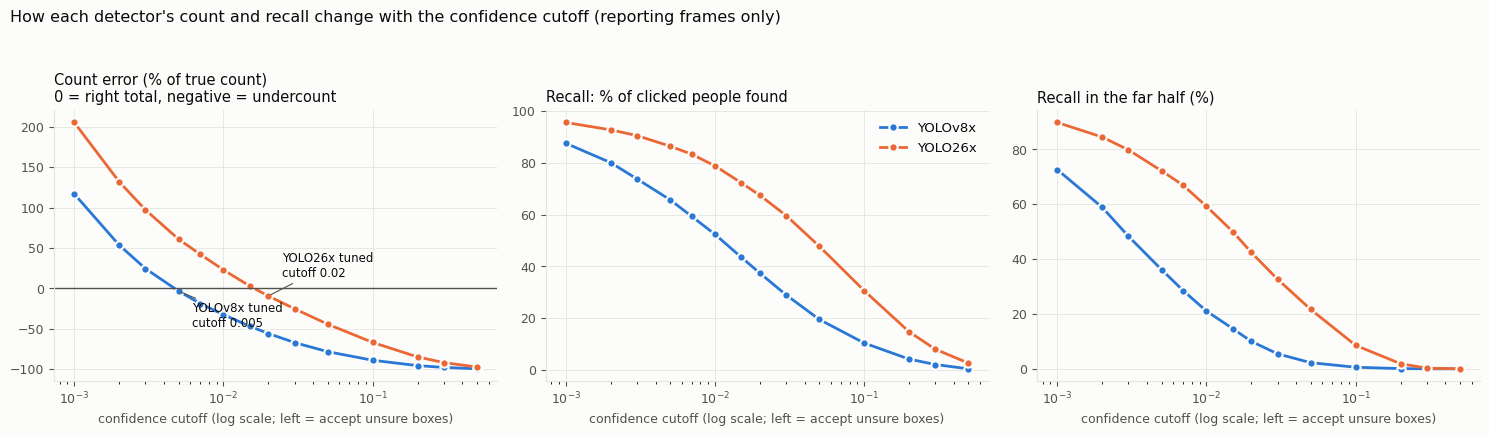

In [12]:
import matplotlib.pyplot as plt

CURVE_GRID = [0.001, 0.002, 0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
COLORS = {"yolov8x.pt": "#2a78d6", "yolo26x.pt": "#eb6834"}     # colour-blind-safe blue and orange (checked with a palette validator)
NICE = {"yolov8x.pt": "YOLOv8x", "yolo26x.pt": "YOLO26x"}         # readable names for labels
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"

def sensitivity_curve(det, fids, grid=CURVE_GRID):
    """For each confidence cutoff, score the reporting frames and return count bias (% of true count), recall and far-field recall."""
    out = []
    for t in grid:
        S = summarise(rows_for(det, fids, t))
        true_mean = np.mean([(pts.frame_id == i).sum() for i in fids])
        out.append(dict(cutoff=t, bias_pct=100 * S["bias"] / true_mean, recall=100 * S["recall"], recall_far=100 * S["recall_far"]))
    return pd.DataFrame(out)

curves = {name: sensitivity_curve(dets[name], test_ids) for name in MODELS}     # reporting frames only

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), facecolor=SURFACE)
panels = [("bias_pct", "Count error (% of true count)\n0 = right total, negative = undercount"),
          ("recall", "Recall: % of clicked people found"),
          ("recall_far", "Recall in the far half (%)")]
for ax, (col, title) in zip(axes, panels):
    ax.set_facecolor(SURFACE)
    for name in MODELS:
        c = curves[name]
        ax.plot(c.cutoff, c[col], "-o", color=COLORS[name], lw=2, ms=6, mec=SURFACE, mew=1.5, label=NICE[name])
    ax.set_xscale("log"); ax.set_title(title, fontsize=10.5, color=INK, loc="left")
    ax.set_xlabel("confidence cutoff (log scale; left = accept unsure boxes)", fontsize=9, color=INK2)
    ax.grid(True, color=GRID, lw=0.6); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9)
axes[0].axhline(0, color=INK2, lw=1)                              # the "exact count" line
best = {n: final.loc[(n, "F1"), "cutoff"] for n in MODELS}         # cutoffs picked on the tuning frames (from Step 7)
for name in MODELS:                                               # label only the cutoff each detector was tuned to
    c = curves[name]; r = c[c.cutoff == best[name]]
    if len(r):
        axes[0].annotate(f"{NICE[name]} tuned\ncutoff {best[name]}", (best[name], r.bias_pct.iloc[0]),
                         textcoords="offset points", xytext=(10, -26 if name == "yolov8x.pt" else 14), fontsize=8.5,
                         color=INK, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
axes[1].legend(frameon=False, fontsize=9.5, labelcolor=INK, loc="upper right")   # empty corner of the recall panel
fig.suptitle("How each detector's count and recall change with the confidence cutoff (reporting frames only)",
             fontsize=11.5, color=INK, x=0.01, ha="left")
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

## Step 8: How touchy is the detector's count?

**In simple words:** a detector has one "how sure must you be" dial (the confidence cutoff). We turn that dial from very loose (left) to very strict (right) and watch three things for both detectors, on the 10 reporting frames only:
1. **Count error:** is the total too high or too low compared with the people we clicked? Zero is a perfect total.
2. **Recall:** what share of the people we clicked did it find?
3. **Far-half recall:** the same, only for the far-away half of the picture.

**What to look for:** if a small turn of the dial flips the count from "too many" to "too few", the detector cannot be used on a new video without someone tuning it first, and the density model does not need that. Each line uses a separate panel, so no panel mixes two different units.